# 02. Hoechst preprocessing

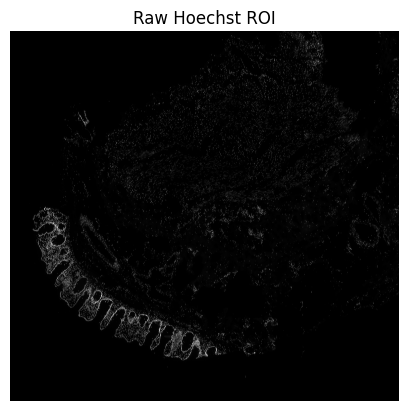

In [2]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from skimage import exposure, filters, morphology

hoechst = tifffile.imread('data/channels/00_Hoechst1.tif')
# ROI_SIZE = 2024
# ROI_CENTER = (5120, 1024)
# cy, cx = ROI_CENTER
# y0 = cy - ROI_SIZE // 2
# x0 = cx - ROI_SIZE // 2
# roi = hoechst[y0:y0 + ROI_SIZE, x0:x0 + ROI_SIZE]
roi = hoechst

plt.imshow(roi, cmap='gray')
plt.title('Raw Hoechst ROI')
plt.axis('off')
plt.show()

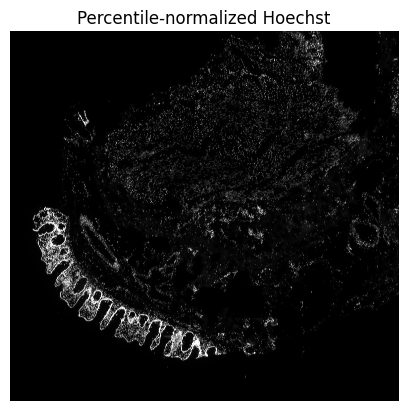

In [3]:
p_low = 1
p_high = 99.7
lo, hi = np.percentile(roi, [p_low, p_high])
hoechst_norm = exposure.rescale_intensity(roi, in_range=(lo, hi), out_range=(0, 1))

plt.imshow(hoechst_norm, cmap='gray')
plt.title('Percentile-normalized Hoechst')
plt.axis('off')
plt.show()

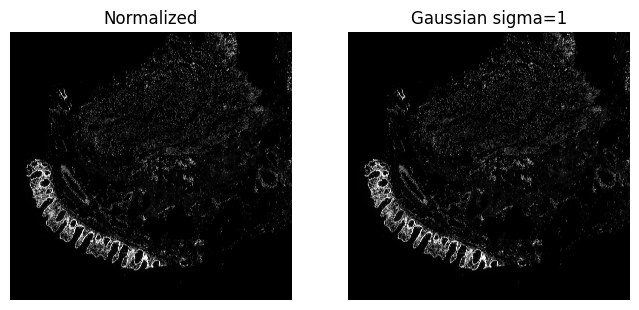

In [4]:
sigma = 1
hoechst_smooth = filters.gaussian(hoechst_norm, sigma=sigma)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(hoechst_norm, cmap='gray')
ax[0].set_title('Normalized')
ax[1].imshow(hoechst_smooth, cmap='gray')
ax[1].set_title(f'Gaussian sigma={sigma}')
for a in ax:
    a.axis('off')
plt.show()

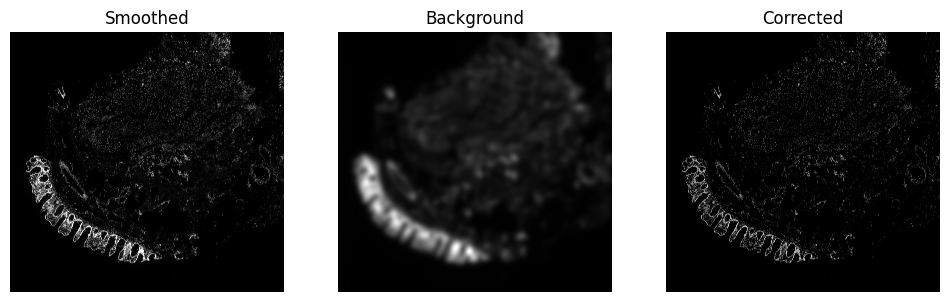

In [5]:
sigma = 100
background = filters.gaussian(hoechst_smooth, sigma=sigma) / 1.5
corrected = np.clip(hoechst_smooth - background, 0, None)
corrected = corrected / corrected.max()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(hoechst_smooth, cmap='gray')
ax[0].set_title('Smoothed')
ax[1].imshow(background, cmap='gray')
ax[1].set_title('Background')
ax[2].imshow(corrected, cmap='gray')
ax[2].set_title('Corrected')
for a in ax:
    a.axis('off')
plt.show()

In [6]:
preprocessed_hoechst = (corrected * 65535).astype('uint16')
tifffile.imwrite('data/preprocessed_hoechst_roi.tif', preprocessed_hoechst)